# NER — Ticker Identification
Strategies: Regex | Dict+Regex | rapidfuzz | BERT NER | LGBM on embeddings

In [1]:
import os, re
from pathlib import Path
from collections import Counter

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from rapidfuzz import process, fuzz
import lightgbm as lgb
from tqdm import tqdm
import os

import torch

from transformers import AutoTokenizer, AutoModel
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
CWD = Path(os.getcwd()).parent
NEWS_PATH = CWD / 'data' / 'preprocessed' / 'subset_news.parquet'


/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
POOL = [
    'AAPL','MSFT','GOOG','GOOGL','AMZN','TSLA','META','NVDA','AMD','INTC','CRM','NFLX',
    'ADBE','PYPL','UBER','SQ','SHOP','ZM','SNAP','COIN','PLTR','ORCL',
    'QQQ','SPY','DIA','IWM',
    'T','VZ',
    'JPM','GS','MS','WFC','BAC','C',
    'XOM','CVX',
    'JNJ','PFE','MRNA','GILD','MRK','UNH','ABT',
    'WMT','COST','TGT','HD','KO','PEP','SBUX','MCD',
    'BA','GE','CAT','MMM',
    'DIS','CMCSA',
    'V','MA',
    'MU','QCOM','TXN','AVGO',
    'F','GM',
]
POOL_SET = set(POOL)

COMPANY_MAP = {
    'Apple': 'AAPL', 'iPhone': 'AAPL', 'iCloud': 'AAPL', 'iPad': 'AAPL',
    'Microsoft': 'MSFT', 'Azure': 'MSFT', 'Windows': 'MSFT', 'Xbox': 'MSFT',
    'Google': 'GOOG', 'Alphabet': 'GOOG', 'YouTube': 'GOOG',
    'Amazon': 'AMZN', 'AWS': 'AMZN',
    'Tesla': 'TSLA',
    'Meta': 'META', 'Facebook': 'META', 'Instagram': 'META', 'WhatsApp': 'META',
    'Nvidia': 'NVDA', 'NVIDIA': 'NVDA', 'GeForce': 'NVDA',
    'Advanced Micro Devices': 'AMD',
    'Intel': 'INTC',
    'Salesforce': 'CRM',
    'Netflix': 'NFLX',
    'Adobe': 'ADBE',
    'PayPal': 'PYPL',
    'Uber': 'UBER',
    'Square': 'SQ',
    'Shopify': 'SHOP',
    'Zoom': 'ZM',
    'Snap': 'SNAP', 'Snapchat': 'SNAP',
    'Coinbase': 'COIN',
    'Palantir': 'PLTR',
    'Oracle': 'ORCL',
    'AT&T': 'T',
    'Verizon': 'VZ',
    'JPMorgan Chase': 'JPM', 'JPMorgan': 'JPM', 'JP Morgan': 'JPM',
    'Goldman Sachs': 'GS',
    'Morgan Stanley': 'MS',
    'Wells Fargo': 'WFC',
    'Bank of America': 'BAC',
    'Citigroup': 'C', 'Citibank': 'C',
    'ExxonMobil': 'XOM', 'Exxon': 'XOM',
    'Chevron': 'CVX',
    'Johnson & Johnson': 'JNJ',
    'Pfizer': 'PFE',
    'Moderna': 'MRNA',
    'Gilead Sciences': 'GILD', 'Gilead': 'GILD',
    'Merck': 'MRK',
    'UnitedHealth': 'UNH',
    'Abbott': 'ABT',
    'Walmart': 'WMT',
    'Costco': 'COST',
    'Target': 'TGT',
    'Home Depot': 'HD',
    'Coca-Cola': 'KO', 'Coca Cola': 'KO',
    'PepsiCo': 'PEP', 'Pepsi': 'PEP',
    'Starbucks': 'SBUX',
    "McDonald's": 'MCD', 'McDonalds': 'MCD',
    'Boeing': 'BA',
    'General Electric': 'GE',
    'Caterpillar': 'CAT',
    '3M': 'MMM',
    'Walt Disney': 'DIS', 'Disney': 'DIS',
    'Comcast': 'CMCSA',
    'Visa': 'V',
    'Mastercard': 'MA',
    'Micron Technology': 'MU', 'Micron': 'MU',
    'Qualcomm': 'QCOM',
    'Texas Instruments': 'TXN',
    'Broadcom': 'AVGO',
    'Ford Motor': 'F', 'Ford': 'F',
    'General Motors': 'GM',
}
COMPANY_MAP_LOWER = {k.lower(): v for k, v in COMPANY_MAP.items()}
COMPANY_NAMES_LIST = list(COMPANY_MAP.keys())
df = pl.read_parquet(NEWS_PATH)
df = df.filter(pl.col('Stock_symbol').is_in(POOL))

In [3]:
df.schema

Schema([('id', UInt32),
        ('Date', String),
        ('Article_title', String),
        ('Stock_symbol', String),
        ('Url', String),
        ('Publisher', String),
        ('Author', String),
        ('Article', String),
        ('Lsa_summary', String),
        ('Luhn_summary', String),
        ('Textrank_summary', String),
        ('Lexrank_summary', String),
        ('date_parsed', Date)])

In [4]:
df = df.with_columns(
    (pl.col('Article_title').fill_null('') + ' ' + pl.col('Article').fill_null('')).alias('text')
)

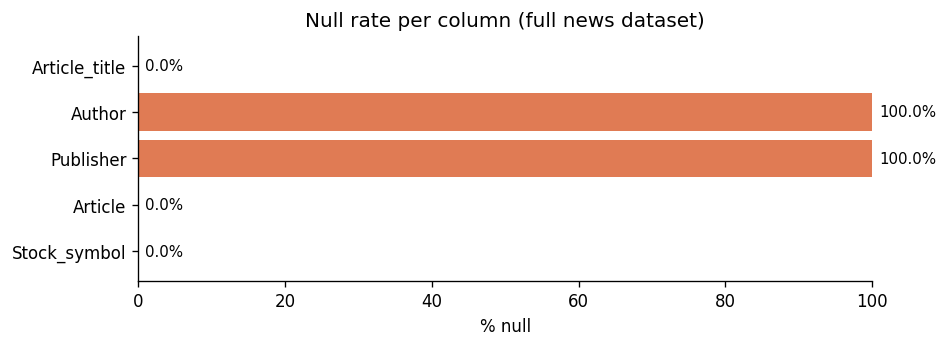

In [5]:
# Null audit on key columns
null_stats = (
    df.select([
        (pl.col(c).is_null().sum() / pl.len() * 100).round(1).alias(c)
        for c in ['Stock_symbol', 'Article', 'Publisher', 'Author', 'Article_title']
    ])
)

cols   = null_stats.columns
pcts   = null_stats.row(0)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(cols, pcts, color='#e07b54')
ax.bar_label(bars, labels=[f'{v}%' for v in pcts], padding=4, fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel('% null')
ax.set_title('Null rate per column (full news dataset)')
plt.tight_layout()
plt.show()

In [6]:
# Print entirely the first two articles
print("Article 1:")
print(df['text'][0])
print("\nArticle 2:")
print(df['text'][1])

Article 1:
Notable Monday Option Activity: COST, GS, GLW Among the underlying components of the S&P 500 index, we saw noteworthy options trading volume today in Costco Wholesale Corp (Symbol: COST), where a total of 19,194 contracts have traded so far, representing approximately 1.9 million underlying shares. That amounts to about 113% of COST's average daily trading volume over the past month of 1.7 million shares. Particularly high volume was seen for the $310 strike call option expiring December 20, 2019, with 1,403 contracts trading so far today, representing approximately 140,300 underlying shares of COST. Below is a chart showing COST's trailing twelve month trading history, with the $310 strike highlighted in orange:
Goldman Sachs Group Inc (the (Symbol: GS) options are showing a volume of 21,955 contracts thus far today. That number of contracts represents approximately 2.2 million underlying shares, working out to a sizeable 112.7% of GS's average daily trading volume over the

In [7]:
print(f"Df shape: ({df.shape[0]:,}, {df.shape[1]:,})")

Df shape: (139,522, 14)


In [8]:
df = pl.read_parquet(NEWS_PATH)
df = df.filter(pl.col('Stock_symbol').is_in(POOL))
df = df.with_columns(
    (pl.col('Article_title').fill_null('') + ' ' + pl.col('Article').fill_null('')).alias('text')
)

# Stratified subsample: keep at most 200 rows per ticker (~5 800 total).
# Keeps class distribution intact while staying well within memory limits.
N_PER_CLASS = 200
df = (
    df.sample(fraction=1.0, shuffle=True, seed=42)
      .with_columns(
          pl.int_range(pl.len()).over('Stock_symbol').alias('_rank')
      )
      .filter(pl.col('_rank') < N_PER_CLASS)
      .drop('_rank')
)

texts = df['text'].to_list()
labels = df['Stock_symbol'].to_list()

tr_idx, te_idx = train_test_split(
    range(len(texts)), test_size=0.2, random_state=42, stratify=labels
)
texts_tr = [texts[i] for i in tr_idx]
labels_tr = [labels[i] for i in tr_idx]
texts_te = [texts[i] for i in te_idx]
labels_te = [labels[i] for i in te_idx]

print(f'Total: {len(df):,}  Train: {len(tr_idx):,}  Test: {len(te_idx):,}')
print(f'Tickers in test: {len(set(labels_te))}')
df['Stock_symbol'].value_counts().sort('count', descending=True).head(10)

Total: 5,546  Train: 4,436  Test: 1,110
Tickers in test: 29


Stock_symbol,count
str,u32
"""V""",200
"""T""",200
"""TSLA""",200
"""WFC""",200
"""GILD""",200
"""SPY""",200
"""PEP""",200
"""GE""",200
"""CAT""",200


## 1. Regex — Candidate Retrieval
Match exact ticker symbols; return ordered candidates (first occurrence = top-1).

In [9]:
# longest-first so GOOGL matches before GOOG
TICKER_RE = re.compile(
    r'\b(' + '|'.join(sorted(POOL, key=len, reverse=True)) + r')\b'
)


class RegexTickerExtractor:
    """Simple regex-based ticker extractor (longest match first)."""

    def __init__(self, pool):
        self.pool = pool
        self.pattern = re.compile(
            r'\b(' + '|'.join(sorted(pool, key=len, reverse=True)) + r')\b'
        )

    def transform(self, texts):
        return [self._extract(t) for t in texts]

    def _extract(self, text):
        seen, ordered = set(), []
        for m in self.pattern.finditer(text):
            t = m.group(1)
            if t not in seen:
                seen.add(t)
                ordered.append(t)
        return ordered

    def score(self, texts, labels):
        cands = self.transform(texts)
        ret_rec = float(np.mean([l in c for l, c in zip(labels, cands)]))
        top1_acc = float(np.mean([c[0] == l if c else False for c, l in zip(cands, labels)]))
        cov = float(np.mean([len(c) > 0 for c in cands]))
        avg_cands = float(np.mean([len(c) for c in cands]))
        return {
            "retrieval_recall": ret_rec,
            "top1_accuracy": top1_acc,
            "coverage": cov,
            "avg_candidates": avg_cands,
        }


## 2. Regex + Company Dict — Selection
Count company-name and ticker hits; pick most frequent (first-mention on tie).

In [10]:
class DictTickerClassifier:
    """Map company names + tickers to a single predicted ticker."""

    def __init__(self, company_map, ticker_pool):
        self.company_map = company_map
        self.company_map_lower = {k.lower(): v for k, v in company_map.items()}

        names_sorted = sorted(company_map.keys(), key=len, reverse=True)
        self.dict_re = re.compile(
            r'(?<!\w)(' + '|'.join(re.escape(n) for n in names_sorted) + r')(?!\w)',
            re.IGNORECASE
        )

        self.ticker_re = re.compile(
            r'\b(' + '|'.join(sorted(ticker_pool, key=len, reverse=True)) + r')\b'
        )

    def predict(self, texts):
        return [self._predict_one(t) for t in texts]

    def _predict_one(self, text):
        hits = []

        for m in self.dict_re.finditer(text):
            ticker = self.company_map_lower.get(m.group(1).lower())
            if ticker:
                hits.append(ticker)

        hits += self.ticker_re.findall(text)

        if not hits:
            return None

        return Counter(hits).most_common(1)[0][0]

    def score(self, texts, labels):
        preds = self.predict(texts)
        top1_acc = float(np.mean([p == l for p, l, in zip(preds, labels)]))
        cov = float(np.mean([p is not None for p in preds]))
        return {
            "top1_accuracy": top1_acc,
            "coverage": cov
        }

## 3. rapidfuzz — Fuzzy Match
Extract capitalised phrases, fuzzy-match against company names, then frequency-select.

In [11]:
class FuzzyTickerClassifier:
    """Fuzzy match capitalized mentions to company names + tickers."""

    def __init__(self, company_map, company_names_list, ticker_pool, threshold=85):
        self.company_map = company_map
        self.company_names_list = company_names_list
        self.threshold = threshold

        self.cap_re = re.compile(r'\b[A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){0,2}\b')
        self.ticker_re = re.compile(
            r'\b(' + '|'.join(sorted(ticker_pool, key=len, reverse=True)) + r')\b'
        )

    def predict(self, texts):
        return [self._predict_one(t) for t in texts]

    def _predict_one(self, text):
        mentions = list(set(self.cap_re.findall(text[:3000])))
        hits = []

        for mention in mentions:
            result = process.extractOne(
                mention,
                self.company_names_list,
                scorer=fuzz.WRatio,
                score_cutoff=self.threshold
            )
            if result:
                hits.append(self.company_map[result[0]])

        hits += self.ticker_re.findall(text[:3000])

        if not hits:
            return None

        return Counter(hits).most_common(1)[0][0]

    def score(self, texts, labels):
        preds = self.predict(texts)
        top1_acc = float(np.mean([p == l for p, l in zip(preds, labels)]))
        cov = float(np.mean([p is not None for p in preds]))
        return {
            "top1_accuracy": top1_acc,
            "coverage": cov
        }

## 4. BERT NER (dslim/bert-base-NER)
Extract ORG entities with a bert-base-cased NER model, then map to tickers via dict/fuzzy.

In [12]:
import spacy

NER_MODEL = 'en_core_web_sm'

def is_cached_spacy(model_name):
    try:
        spacy.load(model_name)
        return True
    except OSError:
        return False

print(f'{NER_MODEL}: {"cached" if is_cached_spacy(NER_MODEL) else "downloading..."}')

if not is_cached_spacy(NER_MODEL):
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', NER_MODEL])

ner_pipe = spacy.load(NER_MODEL)
print('NER pipeline ready')


class SpacyNERTickerClassifier:
    """Use spaCy NER + fuzzy matching to predict a ticker."""

    def __init__(self, ner_pipe, company_map, company_names_list, ticker_pool, pool_set, threshold=82):
        self.ner_pipe = ner_pipe
        self.company_map = company_map
        self.company_names_list = company_names_list
        self.pool_set = pool_set
        self.threshold = threshold

        self.ticker_re = re.compile(
            r'\b(' + '|'.join(sorted(ticker_pool, key=len, reverse=True)) + r')\b'
        )

    def predict(self, texts):
        return [self._predict_one(t) for t in texts]

    def _predict_one(self, text):
        doc = self.ner_pipe(text[:1500])
        orgs = [ent.text for ent in doc.ents if ent.label_ in ('ORG', 'PERSON', 'PRODUCT')]

        hits = []
        for org in orgs:
            if org.upper() in self.pool_set:
                hits.append(org.upper())
                continue

            result = process.extractOne(
                org,
                self.company_names_list,
                score_cutoff=self.threshold
            )
            if result:
                hits.append(self.company_map[result[0]])

        hits += self.ticker_re.findall(text[:1500])

        if not hits:
            return None

        return Counter(hits).most_common(1)[0][0]

    def score(self, texts, labels):
        preds = self.predict(texts)
        top1_acc = float(np.mean([p == l for p, l in zip(preds, labels)]))
        cov = float(np.mean([p is not None for p in preds]))
        return {
            "top1_accuracy": top1_acc,
            "coverage": cov
        }

en_core_web_sm: cached


NER pipeline ready


## 5. LGBM on BERT Embeddings
CLS-token embeddings from bert-base-cased; multi-class LGBM on train split.

In [13]:
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


class TfidfTickerClassifier(BaseEstimator, ClassifierMixin):
    """Char-TFIDF + logistic regression ticker classifier."""

    def __init__(self, max_features=50000, C=3.0):
        self.max_features = max_features
        self.C = C

    def fit(self, X, y):
        self.pipe_ = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    lowercase=False,
                    max_features=self.max_features,
                    sublinear_tf=True,
                )
            ),
            (
                "clf",
                LogisticRegression(
                    C=self.C,
                    max_iter=2000,
                    n_jobs=-1,
                    class_weight="balanced"
                )
            )
        ])
        self.pipe_.fit(X, y)
        return self

    def predict(self, X):
        return self.pipe_.predict(X)

    def predict_proba_top1(self, X):
        proba = self.pipe_.predict_proba(X)
        idx = np.argmax(proba, axis=1)
        conf = proba[np.arange(len(idx)), idx]
        preds = self.pipe_.classes_[idx]
        return preds, conf

    def score(self, X, y):
        preds = self.predict(X)
        return {
            "top1_accuracy": float(accuracy_score(y, preds)),
            "coverage": 1.0,
        }

In [14]:
import re
import unicodedata
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


class PreprocTfidfTickerClassifier(BaseEstimator, ClassifierMixin):
    """TF-IDF with finance/company preprocessing."""

    def __init__(self, max_features=60000, C=3.0):
        self.max_features = max_features
        self.C = C

        self.suffix_repls = {
            " corporation ": " corp ",
            " incorporated ": " inc ",
            " company ": " co ",
            " limited ": " ltd ",
            " public limited company ": " plc ",
            " holdings ": " holding ",
            " technologies ": " technology ",
            " international ": " intl ",
        }

        self.alias_map = {
            "google": "alphabet",
            "facebook": "meta",
            "fb": "meta",
            "instagram": "meta",
            "whatsapp": "meta",
            "youtube": "alphabet",
            "aws": "amazon",
            "whole foods": "amazon",
            "microsoft corp": "microsoft",
            "apple inc": "apple",
            "tesla motors": "tesla",
        }

    def _normalize(self, text):
        text = text[:2000]
        text = unicodedata.normalize("NFKD", text)
        text = text.encode("ascii", "ignore").decode("utf-8", errors="ignore")
        text = text.lower()

        text = re.sub(r"http\S+|www\.\S+", " ", text)
        text = re.sub(r"[$€£]", " money ", text)
        text = re.sub(r"[^a-z0-9\.\-\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        text = f" {text} "
        for k, v in self.suffix_repls.items():
            text = text.replace(k, v)

        for k, v in self.alias_map.items():
            if k in text:
                text += f" {v} "

        return re.sub(r"\s+", " ", text).strip()

    def fit(self, X, y):
        Xp = [self._normalize(x) for x in X]

        self.pipe_ = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    max_features=self.max_features,
                    sublinear_tf=True,
                )
            ),
            (
                "clf",
                LogisticRegression(
                    C=self.C,
                    max_iter=2000,
                    n_jobs=-1,
                    class_weight="balanced"
                )
            )
        ])

        self.pipe_.fit(Xp, y)
        return self

    def predict(self, X):
        Xp = [self._normalize(x) for x in X]
        return self.pipe_.predict(Xp)

    def score(self, X, y):
        preds = self.predict(X)
        return {
            "top1_accuracy": float(accuracy_score(y, preds)),
            "coverage": 1.0,
        }

In [15]:
import re
import unicodedata
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


class RegexRerankTickerClassifier(BaseEstimator, ClassifierMixin):
    """Regex candidates + TF-IDF reranking."""

    def __init__(self, ticker_pool, max_features=60000, C=3.0):
        self.ticker_pool = ticker_pool
        self.max_features = max_features
        self.C = C

        self.ticker_re = re.compile(
            r'\b(' + '|'.join(sorted(ticker_pool, key=len, reverse=True)) + r')\b'
        )

    def _normalize(self, text):
        text = text[:2000]
        text = unicodedata.normalize("NFKD", text)
        text = text.encode("ascii", "ignore").decode("utf-8", errors="ignore")
        text = text.lower()
        text = re.sub(r"http\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z0-9\.\-\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def _candidates(self, text):
        seen, ordered = set(), []
        for m in self.ticker_re.finditer(text):
            t = m.group(1)
            if t not in seen:
                seen.add(t)
                ordered.append(t)
        return ordered

    def fit(self, X, y):
        Xp = [self._normalize(x) for x in X]

        self.vec_ = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=self.max_features,
            sublinear_tf=True,
        )
        Xv = self.vec_.fit_transform(Xp)

        self.clf_ = LogisticRegression(
            C=self.C,
            max_iter=2000,
            n_jobs=-1,
            class_weight="balanced"
        )
        self.clf_.fit(Xv, y)
        self.classes_ = self.clf_.classes_
        self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}
        return self

    def predict(self, X):
        Xp = [self._normalize(x) for x in X]
        Xv = self.vec_.transform(Xp)
        proba = self.clf_.predict_proba(Xv)

        preds = []
        for text_raw, text_p, row in zip(X, Xp, proba):
            cands = self._candidates(text_raw)

            if len(cands) == 1:
                preds.append(cands[0])
                continue

            if len(cands) > 1:
                valid = [c for c in cands if c in self.class_to_idx_]
                if valid:
                    best = max(valid, key=lambda c: row[self.class_to_idx_[c]])
                    preds.append(best)
                    continue

            preds.append(self.classes_[int(np.argmax(row))])

        return preds

    def score(self, X, y):
        preds = self.predict(X)
        return {
            "top1_accuracy": float(accuracy_score(y, preds)),
            "coverage": 1.0,
        }

## Metrics Summary


In [16]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedShuffleSplit


def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    if hasattr(model, "fit"):
        try:
            model.fit(X_tr, y_tr)
        except TypeError:
            model.fit(X_tr)

    if name == "regex_ret":
        cands = model.transform(X_te)
        ret = float(np.mean([y in c for y, c in zip(y_te, cands)]))
        acc = float(np.mean([c[0] == y if c else False for c, y in zip(cands, y_te)]))
        cov = float(np.mean([len(c) > 0 for c in cands]))
    else:
        preds = model.predict(X_te)
        acc = float(np.mean([p == y for p, y in zip(preds, y_te)]))
        ret = acc
        cov = float(np.mean([p is not None for p in preds]))

    return {
        "Retrieval Recall": ret,
        "Top-1 Accuracy": acc,
        "Coverage": cov,
    }


print("Eval models on 5-fold stratified splits")
X = np.array(texts)
y = np.array(labels)

print(f'Total samples: {len(X)}')
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.20, random_state=42)
print(f'Unique tickers: {len(set(y))}')

rows = []
for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y), start=1):
    print(f'\nFold {fold}')
    X_tr, X_te = X[tr_idx].tolist(), X[te_idx].tolist()
    y_tr, y_te = y[tr_idx].tolist(), y[te_idx].tolist()

    models = {
        "regex_ret": RegexTickerExtractor(POOL),
        "dict_rx": DictTickerClassifier(COMPANY_MAP, POOL),
        "fuzzy": FuzzyTickerClassifier(COMPANY_MAP, COMPANY_NAMES_LIST, POOL),
        # "spacy_ner": SpacyNERTickerClassifier(
        #     ner_pipe, COMPANY_MAP, COMPANY_NAMES_LIST, POOL, POOL_SET
        # ),
        'tfidf': TfidfTickerClassifier(max_features=50000, C=3.0),
        "preproc_tfidf": PreprocTfidfTickerClassifier(max_features=60000, C=3.0),
        "regex_rerank": RegexRerankTickerClassifier(POOL, max_features=60000, C=3.0),
    }

    for name, model in tqdm(models.items(), desc=f"Fold {fold}", leave=True):
        print(f"Evaluating {name}...")
        scores = eval_model(name, model, X_tr, y_tr, X_te, y_te)
        rows.append({
            "Fold": fold,
            "Strategy": name,
            **scores
        })

df_cv = pl.DataFrame(rows)
print(df_cv)

Eval models on 5-fold stratified splits
Total samples: 5546
Unique tickers: 29



Fold 1


Fold 1:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating regex_ret...
Evaluating dict_rx...


Evaluating fuzzy...


...

Evaluating preproc_tfidf...


/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Evaluating regex_rerank...


/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


shape: (30, 5)
┌──────┬───────────────┬──────────────────┬────────────────┬──────────┐
│ Fold ┆ Strategy      ┆ Retrieval Recall ┆ Top-1 Accuracy ┆ Coverage │
│ ---  ┆ ---           ┆ ---              ┆ ---            ┆ ---      │
│ i64  ┆ str           ┆ f64              ┆ f64            ┆ f64      │
╞══════╪═══════════════╪══════════════════╪════════════════╪══════════╡
│ 1    ┆ regex_ret     ┆ 0.854054         ┆ 0.526126       ┆ 0.91982  │
│ 1    ┆ dict_rx       ┆ 0.591892         ┆ 0.591892       ┆ 0.977477 │
│ 1    ┆ fuzzy         ┆ 0.500901         ┆ 0.500901       ┆ 0.986486 │
│ 1    ┆ tfidf         ┆ 0.837838         ┆ 0.837838       ┆ 1.0      │
│ 1    ┆ preproc_tfidf ┆ 0.724324         ┆ 0.724324       ┆ 1.0      │
│ …    ┆ …             ┆ …                ┆ …              ┆ …        │
│ 5    ┆ dict_rx       ┆ 0.609009         ┆ 0.609009       ┆ 0.983784 │
│ 5    ┆ fuzzy         ┆ 0.525225         ┆ 0.525225       ┆ 0.988288 │
│ 5    ┆ tfidf         ┆ 0.827027         ┆ 0.827

In [17]:
df_res = (
    df_cv
    .group_by("Strategy")
    .agg([
        pl.col("Retrieval Recall").mean().alias("Retrieval Recall"),
        pl.col("Top-1 Accuracy").mean().alias("Top-1 Accuracy"),
        pl.col("Coverage").mean().alias("Coverage"),
    ])
    .sort("Strategy")
)

print(df_res)

shape: (6, 4)
┌───────────────┬──────────────────┬────────────────┬──────────┐
│ Strategy      ┆ Retrieval Recall ┆ Top-1 Accuracy ┆ Coverage │
│ ---           ┆ ---              ┆ ---            ┆ ---      │
│ str           ┆ f64              ┆ f64            ┆ f64      │
╞═══════════════╪══════════════════╪════════════════╪══════════╡
│ dict_rx       ┆ 0.603964         ┆ 0.603964       ┆ 0.983964 │
│ fuzzy         ┆ 0.52             ┆ 0.52           ┆ 0.987748 │
│ preproc_tfidf ┆ 0.738378         ┆ 0.738378       ┆ 1.0      │
│ regex_rerank  ┆ 0.828288         ┆ 0.828288       ┆ 1.0      │
│ regex_ret     ┆ 0.864324         ┆ 0.547748       ┆ 0.922883 │
│ tfidf         ┆ 0.84018          ┆ 0.84018        ┆ 1.0      │
└───────────────┴──────────────────┴────────────────┴──────────┘


In [18]:
results = {
    "Strategy": df_res["Strategy"].to_list(),
    "Retrieval Recall": df_res["Retrieval Recall"].to_list(),
    "Top-1 Accuracy": df_res["Top-1 Accuracy"].to_list(),
    "Coverage": df_res["Coverage"].to_list(),
}

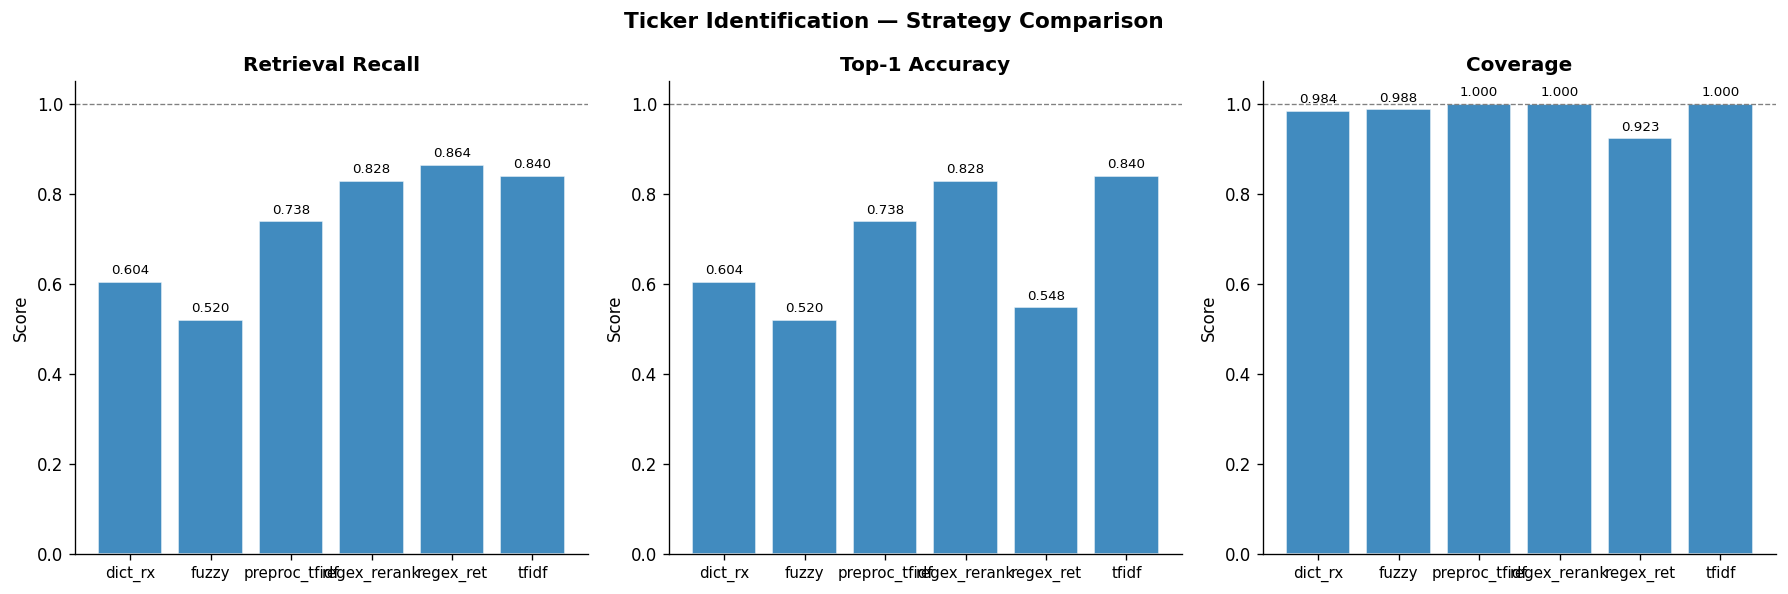

In [19]:
strategies = results["Strategy"]
x = np.arange(len(strategies))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Ticker Identification — Strategy Comparison", fontsize=13, fontweight="bold")

metrics = [
    ("Retrieval Recall", results["Retrieval Recall"]),
    ("Top-1 Accuracy", results["Top-1 Accuracy"]),
    ("Coverage", results["Coverage"]),
]

for ax, (title, vals) in zip(axes, metrics):
    bars = ax.bar(x, vals, alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Score")
    ax.axhline(1.0, color="grey", lw=0.8, linestyle="--")

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.01,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

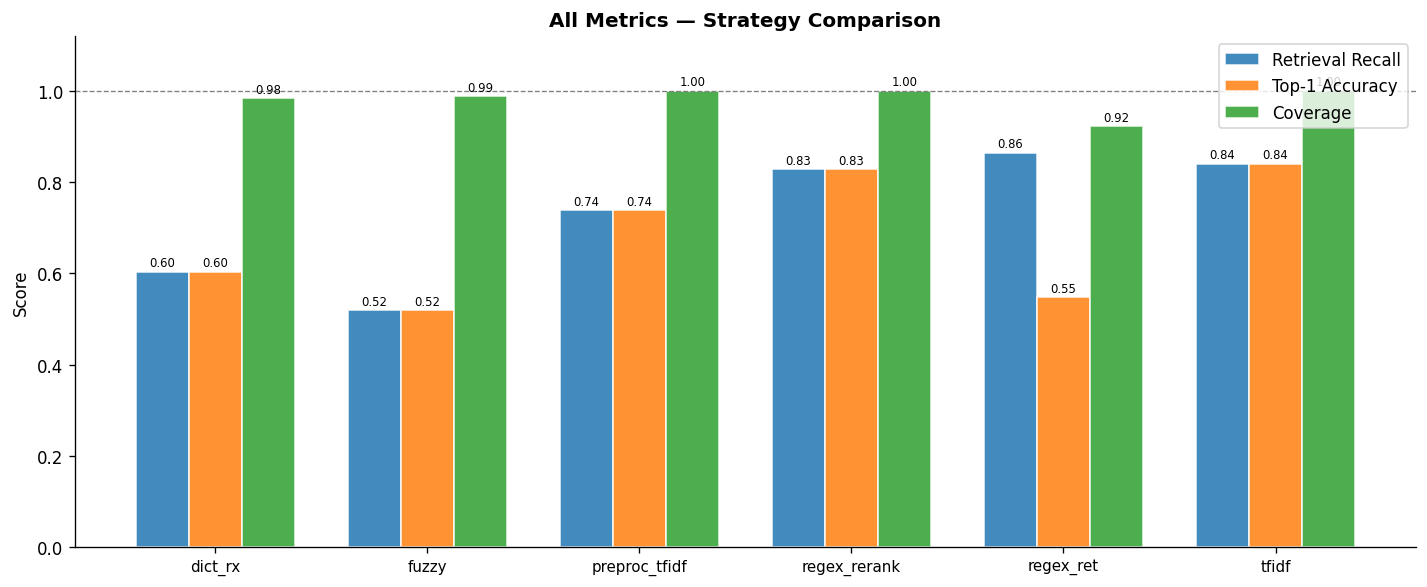

In [20]:
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

metrics = ["Retrieval Recall", "Top-1 Accuracy", "Coverage"]
offsets = [-width, 0, width]

for offset, metric in zip(offsets, metrics):
    vals = results[metric]
    bars = ax.bar(x + offset, vals, width, label=metric, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.005,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("All Metrics — Strategy Comparison", fontweight="bold")
ax.legend()
ax.axhline(1.0, color="grey", lw=0.8, linestyle="--")

plt.tight_layout()
plt.show()

## **Export top model**

In [21]:
# Select best strategy by Top-1 Accuracy and fit on the full sample
best_row = df_res.sort("Top-1 Accuracy", descending=True).row(0)
best_strategy = best_row[0]
print(f"Best strategy by Top-1 Accuracy: {best_strategy}")

best_model = models[best_strategy]
best_model.fit(X, y)

import joblib
MODEL_PATH = os.path.join(CWD, "models", f"ticker_ner_{best_strategy}.joblib")
joblib.dump(best_model, MODEL_PATH)
print(f"Saved best model to {MODEL_PATH}")


Best strategy by Top-1 Accuracy: tfidf


/opt/anaconda3/envs/ie_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Saved best model to /Users/armandhubler/Documents/coding_project/nlp_project/models/ticker_ner_tfidf.joblib


In [22]:
# Run inference on the full news df (filtered to POOL) and save as parquet.
# Toggle SAMPLE=False to run on the full df.
SAMPLE = True
SAMPLE_SIZE = 1000

df_full = pl.read_parquet(NEWS_PATH).filter(pl.col("Stock_symbol").is_in(POOL))
df_full = df_full.with_columns(
    (pl.col("Article_title").fill_null("") + " " + pl.col("Article").fill_null("")).alias("text")
)

if SAMPLE:
    df_infer = df_full.sample(n=min(SAMPLE_SIZE, df_full.height), seed=42)
    out_name = f"ner_predictions_{best_strategy}_sample.parquet"
else:
    df_infer = df_full
    out_name = f"ner_predictions_{best_strategy}_full.parquet"

print(f"Running inference on {df_infer.height:,} rows (SAMPLE={SAMPLE})...")
preds = best_model.predict(df_infer["text"].to_list())

df_out = df_infer.with_columns(pl.Series("predicted_ticker", preds))
OUT_PATH = CWD / "data" / out_name
df_out.write_parquet(OUT_PATH)
print(f"Saved predictions to {OUT_PATH}  shape={df_out.shape}")

acc = float(np.mean([p == y for p, y in zip(preds, df_infer["Stock_symbol"].to_list())]))
print(f"Top-1 accuracy vs Stock_symbol on inference set: {acc:.4f}")


Running inference on 1,000 rows (SAMPLE=True)...


Saved predictions to /Users/armandhubler/Documents/coding_project/nlp_project/data/ner_predictions_tfidf_sample.parquet  shape=(1000, 15)
Top-1 accuracy vs Stock_symbol on inference set: 0.8610
